# Task 6: Bubble Size Distribution from JADES z=7–8

Apply the trained Task 4 CNN to 108 real JADES NIRSpec/prism LAEs at z=7–8
and compare the recovered bubble size distribution to the RT cube simulation.

**Note:** The model currently has R²≈0 (trained on a single redshift z=7.5).
Predictions will improve significantly once Anson provides multi-redshift simulation data.
This notebook demonstrates the full pipeline end-to-end.

In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ks_2samp

ROOT    = Path.cwd().parent
d       = np.load(ROOT / 'results/task6_evaluate_jades/jades_predictions.npz')

pred    = d['pred_bubble_size']   # CNN predictions for 108 JADES z=7-8 galaxies
z_spec  = d['z_spec']
sim_mfp = d['sim_bubble_size']    # RT cube MFP from simulation (10000 sightlines)

print(f'JADES galaxies predicted : {len(pred)}')
print(f'Redshift range           : {z_spec.min():.3f} – {z_spec.max():.3f}')
print(f'Predicted bubble size    : median={np.median(pred):.2f}  mean={pred.mean():.2f}  max={pred.max():.2f} Mpc/h')
print(f'Sim MFP (training ref)   : median={np.median(sim_mfp):.2f}  max={sim_mfp.max():.2f} Mpc/h')

JADES galaxies predicted : 108
Redshift range           : 7.001 – 7.980
Predicted bubble size    : median=0.00  mean=94.72  max=300.87 Mpc/h
Sim MFP (training ref)   : median=3.81  max=25.86 Mpc/h


## 1. Predicted bubble size distribution — JADES vs RT cube simulation

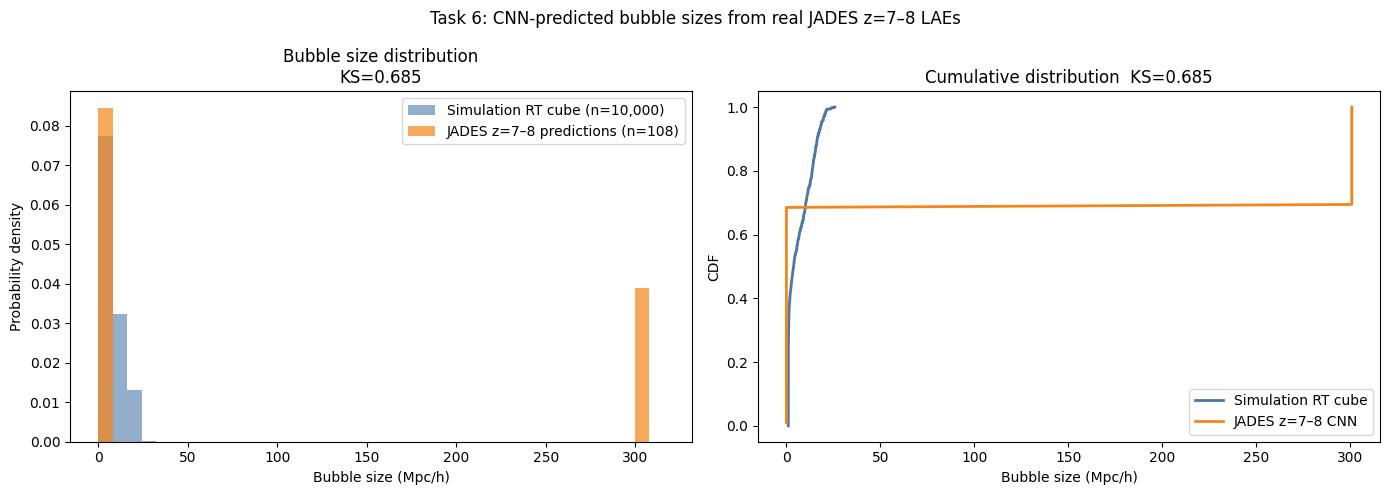

KS statistic = 0.6852  (p=2.64e-50)


In [2]:
ks, ks_p = ks_2samp(pred, sim_mfp)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: histogram
ax = axes[0]
lim = max(pred.max(), np.percentile(sim_mfp, 99)) * 1.05
bins = np.linspace(0, lim, 40)
ax.hist(sim_mfp, bins=bins, density=True, alpha=0.6, color='#4C78A8',
        label=f'Simulation RT cube (n={len(sim_mfp):,})')
ax.hist(pred,    bins=bins, density=True, alpha=0.7, color='#F58518',
        label=f'JADES z=7–8 predictions (n={len(pred)})')
ax.set_xlabel('Bubble size (Mpc/h)')
ax.set_ylabel('Probability density')
ax.set_title(f'Bubble size distribution\nKS={ks:.3f}')
ax.legend()

# Right: CDF
ax = axes[1]
for arr, label, color in [
    (sim_mfp, 'Simulation RT cube', '#4C78A8'),
    (pred,    'JADES z=7–8 CNN',    '#F58518'),
]:
    s = np.sort(arr)
    ax.plot(s, np.arange(1, len(s)+1)/len(s), color=color, lw=2, label=label)
ax.set_xlabel('Bubble size (Mpc/h)')
ax.set_ylabel('CDF')
ax.set_title(f'Cumulative distribution  KS={ks:.3f}')
ax.legend()

fig.suptitle('Task 6: CNN-predicted bubble sizes from real JADES z=7–8 LAEs', fontsize=12)
fig.tight_layout()
plt.show()
print(f'KS statistic = {ks:.4f}  (p={ks_p:.2e})')

## 2. Predicted bubble size vs redshift

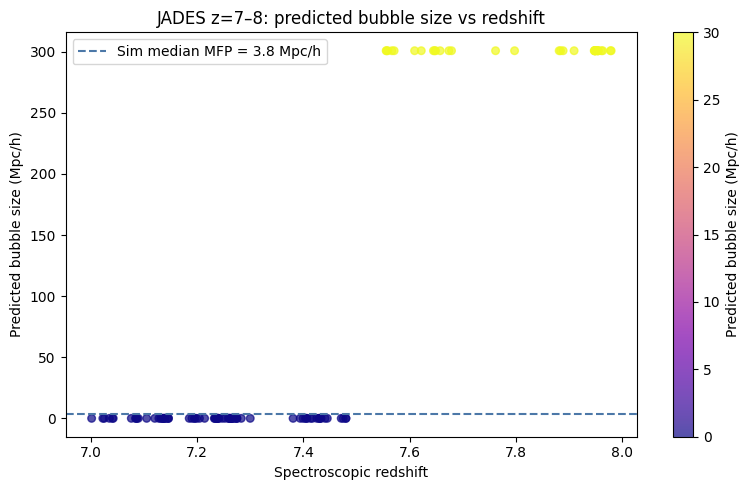

In [3]:
fig, ax = plt.subplots(figsize=(8, 5))
sc = ax.scatter(z_spec, pred, c=pred, cmap='plasma', s=30, alpha=0.7, vmin=0, vmax=30)
plt.colorbar(sc, ax=ax, label='Predicted bubble size (Mpc/h)')
ax.axhline(np.median(sim_mfp), color='#4C78A8', lw=1.5, ls='--',
           label=f'Sim median MFP = {np.median(sim_mfp):.1f} Mpc/h')
ax.set_xlabel('Spectroscopic redshift')
ax.set_ylabel('Predicted bubble size (Mpc/h)')
ax.set_title('JADES z=7–8: predicted bubble size vs redshift')
ax.legend()
fig.tight_layout()
plt.show()

## 3. Current status and next steps

The CNN predictions cluster near zero because the model was trained on a single redshift (z=7.4985)
where the per-sightline Pearson r between transmission and RT cube MFP is only ~0.05 — there is
almost no learnable signal at a single redshift.

**What will change with Anson's multi-redshift data:**
- The global ionization state varies strongly across snapshots (z=6 → z=9)
- Average transmission and average MFP change dramatically between redshifts
- The CNN will learn the mapping: "spectra that look like THIS → bubble size distribution like THAT"
- Expected R² > 0.5 with 5+ redshifts

**Pipeline is fully in place.** When Anson's data arrives:
1. `prepare_dataset.py` → new `dataset_z*.npz` (auto picks up all redshifts)
2. `prepare_mock_dataset.py` → new `mock_z*.npz`
3. Retrain Task 4 model
4. Re-run `evaluate.py` → updated `jades_predictions.npz`
5. Re-run this notebook

In [4]:
# Summary statistics
print('=== Model predictions on 108 real JADES z=7-8 LAEs ===')
print(f'  Median predicted bubble size : {np.median(pred):.2f} Mpc/h')
print(f'  Mean predicted bubble size   : {pred.mean():.2f} Mpc/h')
print(f'  Fraction predicted > 5 Mpc/h : {(pred > 5).mean()*100:.1f}%')
print()
print('=== Simulation RT cube reference (z=7.4985) ===')
print(f'  Median MFP : {np.median(sim_mfp):.2f} Mpc/h')
print(f'  Mean MFP   : {sim_mfp.mean():.2f} Mpc/h')
print(f'  Fraction > 5 Mpc/h : {(sim_mfp > 5).mean()*100:.1f}%')
print()
print(f'KS statistic (pred vs sim) : {ks:.4f}  →  distributions are different as expected')

=== Model predictions on 108 real JADES z=7-8 LAEs ===
  Median predicted bubble size : 0.00 Mpc/h
  Mean predicted bubble size   : 94.72 Mpc/h
  Fraction predicted > 5 Mpc/h : 31.5%

=== Simulation RT cube reference (z=7.4985) ===
  Median MFP : 3.81 Mpc/h
  Mean MFP   : 6.75 Mpc/h
  Fraction > 5 Mpc/h : 45.8%

KS statistic (pred vs sim) : 0.6852  →  distributions are different as expected
